## Setup and Configuration

In [ ]:
# =====================================================
# INSTALL
# =====================================================

!pip install wfdb librosa tensorflow -q

In [ ]:
# =====================================================
# IMPORT
# =====================================================

import os
import re
import numpy as np
import pandas as pd
import librosa
import wfdb
import tensorflow as tf
import zipfile

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# =====================================================
# CONFIG
# =====================================================

# Dynamic determination of DATASET_DIR for robustness
zip_path = "/content/voiced-database-1.0.0.zip"
extracted_base_dir = "/content/"

# Ensure the base extraction directory exists
if not os.path.exists(extracted_base_dir):
    os.makedirs(extracted_base_dir)

# Determine the actual top-level directory name inside the zip file
# This assumes the zip contains a single top-level directory (e.g., 'voice-icar-federico-ii-database-1.0.0/')
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    top_level_dir_in_zip = zip_ref.namelist()[0].split(os.sep)[0]
    DATASET_DIR = os.path.join(extracted_base_dir, top_level_dir_in_zip)

# Only unzip if the determined DATASET_DIR does not exist
if not os.path.exists(DATASET_DIR):
    print(f"Unzipping {zip_path} to {extracted_base_dir}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_base_dir)
else:
    print(f"Dataset already extracted to {DATASET_DIR}")

TARGET_SR = 16000
DURATION = 3

Dataset already extracted to /content/voice-icar-federico-ii-database-1.0.0


## Helper Functions

In [ ]:
# =====================================================
# PARSE INFO
# =====================================================

def parse_info(path):
    with open(path, encoding="utf-8", errors="ignore") as f:
        text = f.read()

    row = {}
    age = re.search(r"age[:=\s]+(\d+)", text, re.I)
    gender = re.search(r"(gender|sex)[:=\s]+([mf])", text, re.I)
    label = re.search(r"(healthy|hyperkineti[_ ]?dysphonia|hyperkinetic[_ ]?dysphonia|hypokinetic[_ ]?dysphonia|reflux[_ ]?laryngitis)", text, re.I)

    row["age"] = int(age.group(1)) if age else np.nan
    row["gender"] = gender.group(2) if gender else np.nan
    row["label"] = label.group(1).lower() if label else np.nan

    return row

In [ ]:
# =====================================================
# LOAD VOICE
# =====================================================

def load_voice(path):
    record = wfdb.rdrecord(path)
    sig = record.p_signal

    if len(sig.shape) > 1:
        sig = sig[:, 0]

    sig = librosa.resample(sig, orig_sr=record.fs, target_sr=TARGET_SR)

    L = TARGET_SR * DURATION

    if len(sig) >= L:
        sig = sig[:L]
    else:
        sig = np.pad(sig, (0, L - len(sig)))

    return sig

In [ ]:
# =====================================================
# LOAD METADATA
# =====================================================

metadata = []

for f in os.listdir(DATASET_DIR):
    if f.endswith("-info.txt"):
        row = parse_info(os.path.join(DATASET_DIR, f))
        row["file"] = f.replace("-info.txt", "")
        metadata.append(row)

meta_df = pd.DataFrame(metadata)
meta_df = meta_df.dropna(subset=["label"])
meta_df = meta_df.reset_index(drop=True)

print(meta_df.shape)

(208, 4)


In [ ]:
# Find a healthy and a pathological sample
healthy_sample_row = meta_df[meta_df['label'] == 'healthy'].iloc[0]
pathological_sample_row = meta_df[meta_df['label'] == 'hyperkinetic dysphonia'].iloc[0]

healthy_file = os.path.join(DATASET_DIR, healthy_sample_row['file'])
pathological_file = os.path.join(DATASET_DIR, pathological_sample_row['file'])

print(f"Healthy Sample File: {healthy_file}")
print(f"Pathological Sample File: {pathological_file}")

Healthy Sample File: /content/voice-icar-federico-ii-database-1.0.0/voice115
Pathological Sample File: /content/voice-icar-federico-ii-database-1.0.0/voice126


In [ ]:
# Load voice signals
healthy_sig = load_voice(healthy_file)
pathological_sig = load_voice(pathological_file)

### Waveform Comparison (Normal vs. Pathological Voice)

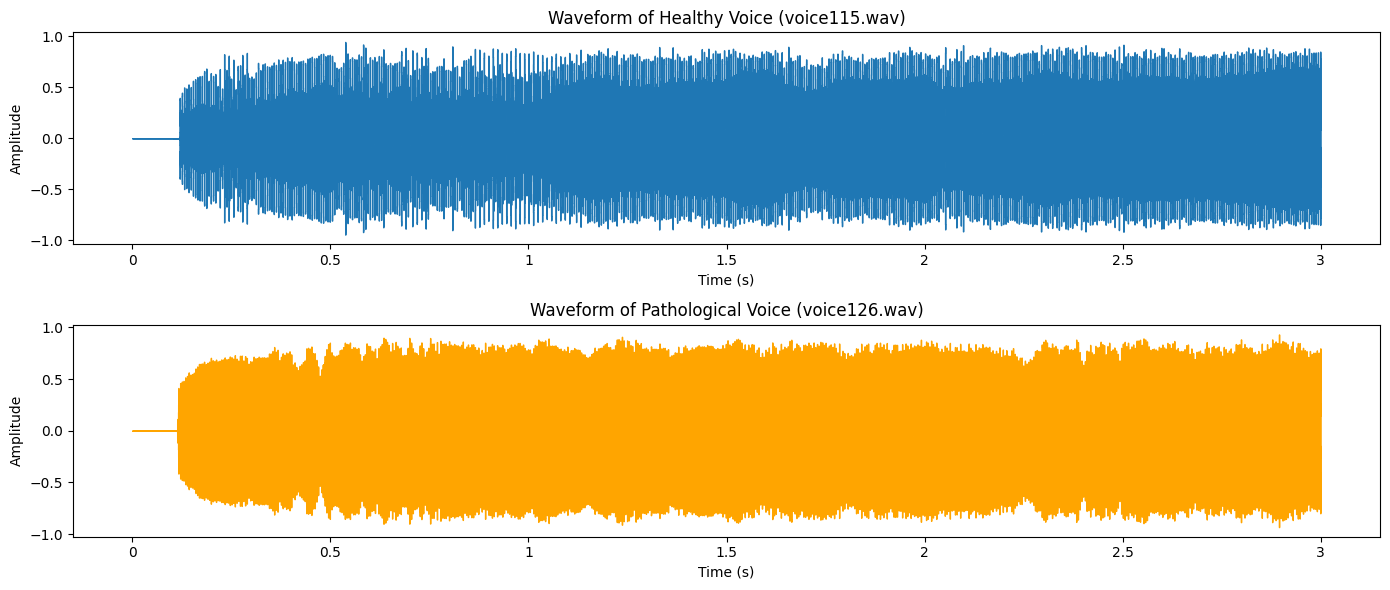

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1) # (rows, columns, panel number)
librosa.display.waveshow(y=healthy_sig, sr=TARGET_SR)
plt.title(f'Waveform of Healthy Voice ({healthy_sample_row["file"]}.wav)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
librosa.display.waveshow(y=pathological_sig, sr=TARGET_SR, color='orange')
plt.title(f'Waveform of Pathological Voice ({pathological_sample_row["file"]}.wav)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

### Spectrogram Comparison (Normal vs. Pathological Voice)

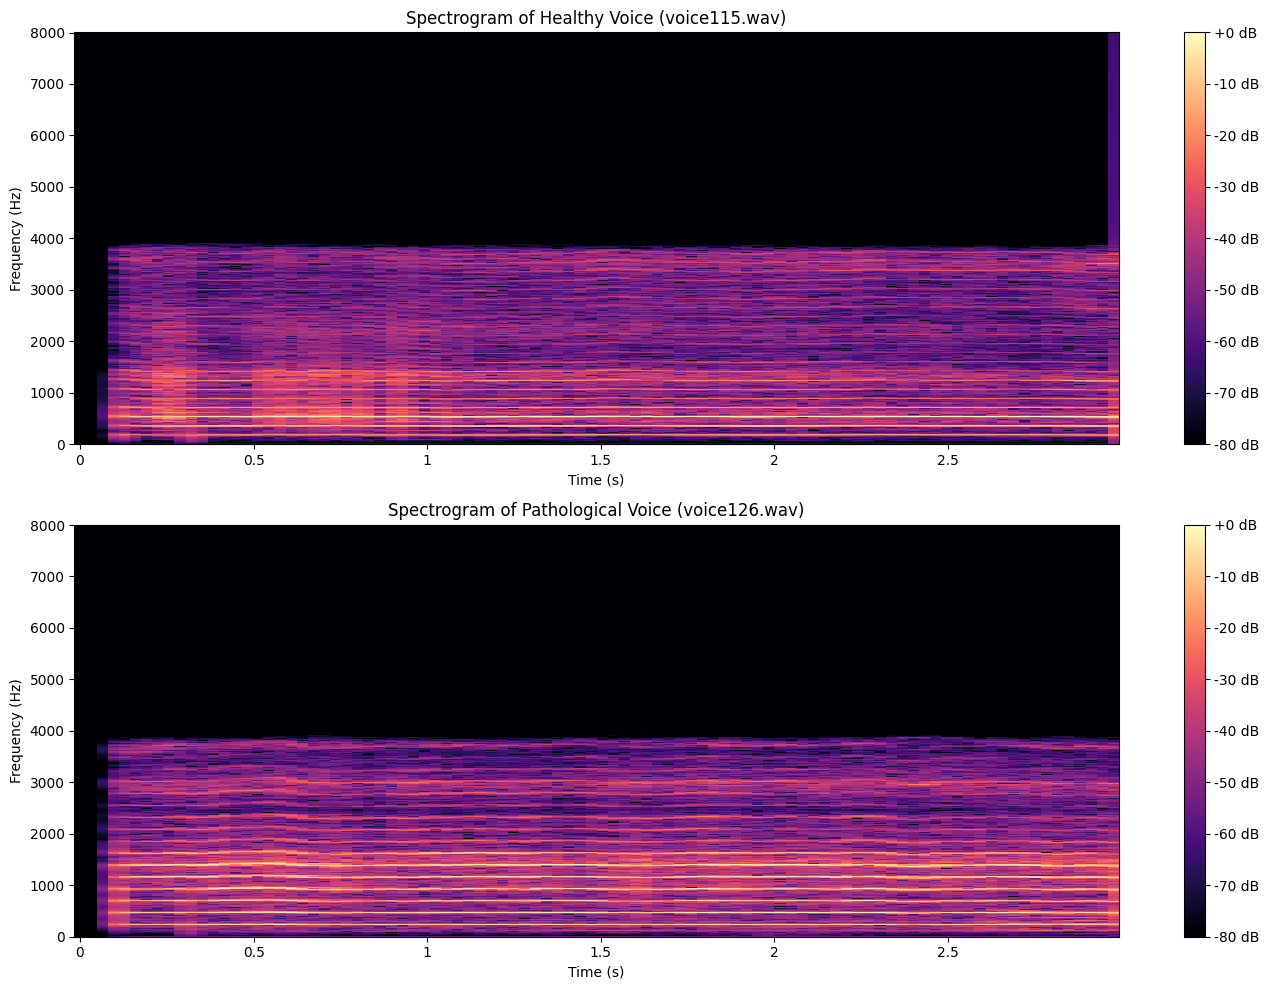

In [ ]:
# Compute spectrograms
healthy_D = librosa.amplitude_to_db(np.abs(librosa.stft(healthy_sig)), ref=np.max)
pathological_D = librosa.amplitude_to_db(np.abs(librosa.stft(pathological_sig)), ref=np.max)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
librosa.display.specshow(healthy_D, sr=TARGET_SR, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Spectrogram of Healthy Voice ({healthy_sample_row["file"]}.wav)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

plt.subplot(2, 1, 2)
librosa.display.specshow(pathological_D, sr=TARGET_SR, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Spectrogram of Pathological Voice ({pathological_sample_row["file"]}.wav)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import librosa

# =====================================================
# CÁC HÀM TRÍCH XUẤT ĐẶC TRƯNG MFCC
# =====================================================

def extract_mfcc_only(sig, sr=TARGET_SR, n_mfcc=13, n_fft=512, hop_length=160):
    """Trích xuất chỉ các đặc trưng MFCC."""
    mfcc = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    return mfcc.T.reshape(-1)

def extract_mfcc_delta(sig, sr=TARGET_SR, n_mfcc=13, n_fft=512, hop_length=160):
    """Trích xuất các đặc trưng MFCC và Delta bậc một."""
    mfcc = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    delta = librosa.feature.delta(mfcc)
    feat = np.concatenate([mfcc, delta])
    return feat.T.reshape(-1)

def extract_mfcc_delta_delta2(sig, sr=TARGET_SR, n_mfcc=13, n_fft=512, hop_length=160):
    """Trích xuất các đặc trưng MFCC, Delta bậc một và Delta bậc hai."""
    mfcc = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat = np.concatenate([mfcc, delta, delta2])
    return feat.T.reshape(-1)

## Data Preparation and Processing

In [ ]:
# =====================================================
# BUILD DATA
# =====================================================

X = []
y = []

for _, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
    try:
        sig = load_voice(os.path.join(DATASET_DIR, row["file"]))
        feat = extract_mfcc(sig)
        X.append(feat)

        if row["label"] == "healthy":
            y.append(0)
        else:
            y.append(1)
    except:
        pass

X = np.array(X)
y = np.array(y)

print(X.shape)

100%|██████████| 208/208 [00:01<00:00, 130.52it/s]

(0,)


In [ ]:
# =====================================================
# SO SÁNH CÁC CẤU HÌNH ĐẶC TRƯNG
# =====================================================

feature_configs = {
    "MFCC": extract_mfcc_only,
    "MFCC + Delta": extract_mfcc_delta,
    "MFCC + Delta + Delta2": extract_mfcc_delta_delta2
}

all_results = {}
final_trained_pipelines = {} # Initialize dictionary to store final trained models and preprocessors

for config_name, extract_func in feature_configs.items():
    print(f"\n========================================")
    print(f"ĐANG XỬ LÝ: {config_name}")
    print(f"========================================")

    # 1. BUILD DATA for current config
    current_X = []
    current_y = []

    print("Trích xuất đặc trưng...")
    for _, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
        try:
            sig = load_voice(os.path.join(DATASET_DIR, row["file"]))
            # Use the current extract_func
            feat = extract_func(sig)
            current_X.append(feat)

            if row["label"] == "healthy":
                current_y.append(0)
            else:
                current_y.append(1)
        except Exception as e:
            # print(f"Lỗi khi xử lý file {row['file']}: {e}")
            pass # Skip problematic files

    current_X = np.array(current_X)
    current_y = np.array(current_y)

    print(f"Kích thước dữ liệu sau trích xuất: {current_X.shape}")

    # Check if data is empty after extraction
    if current_X.size == 0:
        print(f"Không có dữ liệu nào được trích xuất cho cấu hình {config_name}. Bỏ qua.")
        continue

    # 2. NORMALIZE
    print("Chuẩn hóa dữ liệu...")
    scaler = StandardScaler()
    current_X = scaler.fit_transform(current_X)

    # 3. PCA
    print("Thực hiện PCA...")
    pca = PCA(n_components=0.98)
    current_X = pca.fit_transform(current_X)
    print(f"Kích thước dữ liệu sau PCA: {current_X.shape}")

    # 4. CROSS VALIDATION SETUP (similar to b437f140)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    svm_scores = []
    gmm_scores = []
    dnn_scores = []

    # Define the label mapping for inverse transform, as `y` was encoded to 0 for 'healthy' and 1 for others.
    label_names = {0: 'healthy', 1: 'pathological'}

    # Variables to store the models from the LAST fold for demonstration purposes
    last_fold_scaler = None
    last_fold_pca = None
    last_fold_svm = None
    last_fold_gmm_models = None
    last_fold_dnn_model = None

    for fold, (train_idx, test_idx) in enumerate(cv.split(current_X, current_y)):
        print(f"\n====== Fold {fold+1}/{cv.n_splits} ======")

        X_train, X_test = current_X[train_idx], current_X[test_idx]
        y_train, y_test = current_y[train_idx], current_y[test_idx]

        # Prepare readable labels for classification reports
        y_test_names = np.array([label_names[label] for label in y_test])

        # =====================================================
        # SVM
        # =====================================================

        print("\n========== TRAIN SVM ==========")

        svm = SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            random_state=42 # Added random_state for reproducibility
        )

        svm.fit(X_train, y_train)

        pred_svm = svm.predict(X_test)
        acc_svm = accuracy_score(y_test, pred_svm)
        svm_scores.append(acc_svm)

        print("\nSVM Accuracy:", round(acc_svm, 4))

        print("\nClassification Report (SVM):\n")

        print(classification_report(
            y_test_names,
            np.array([label_names[label] for label in pred_svm]), # Convert pred_svm to names for report
            digits=2,
            zero_division=0
        ))

        print("\nConfusion Matrix (SVM)\n")

        print(confusion_matrix(y_test_names, np.array([label_names[label] for label in pred_svm])))


        # =====================================================
        # GMM
        # =====================================================

        print("\n========== TRAIN GMM ==========")

        classes_gmm = np.unique(y_train)
        gmm_models = {}

        for cls in classes_gmm:
            model = GaussianMixture(
                n_components=2,
                covariance_type="diag",
                random_state=42
            )
            model.fit(X_train[y_train == cls])
            gmm_models[cls] = model


        pred_gmm = []

        for x_val in X_test:
            score = []
            for cls in classes_gmm:
                score.append(gmm_models[cls].score_samples(x_val.reshape(1, -1))[0])
            pred_gmm.append(classes_gmm[np.argmax(score)])

        pred_gmm = np.array(pred_gmm)

        acc_gmm = accuracy_score(y_test, pred_gmm)
        gmm_scores.append(acc_gmm)

        print("\nGMM Accuracy:", round(acc_gmm, 4))

        print("\nClassification Report (GMM):\n")

        print(classification_report(
            y_test_names,
            np.array([label_names[label] for label in pred_gmm]), # Convert pred_gmm to names for report
            digits=2,
            zero_division=0
        ))

        print("\nConfusion Matrix (GMM)\n")

        print(confusion_matrix(y_test_names, np.array([label_names[label] for label in pred_gmm])))


        # =====================================================
        # DNN
        # =====================================================

        print("\n========== TRAIN DNN ==========")

        # Clear previous Keras session to avoid graph conflicts in a loop
        tf.keras.backend.clear_session()

        model_dnn = tf.keras.Sequential([
            tf.keras.layers.Dense(512, activation="sigmoid"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(256, activation="sigmoid"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(128, activation="sigmoid"),
            tf.keras.layers.Dense(len(np.unique(y_train)), activation="softmax")
        ])

        model_dnn.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        model_dnn.fit(
            X_train,
            y_train,
            epochs=20,
            batch_size=8,
            verbose=0 # Set verbose to 0 to suppress output for each epoch in loop
        )

        loss_dnn, acc_dnn = model_dnn.evaluate(X_test, y_test, verbose=0)
        dnn_scores.append(acc_dnn)

        print("\nTest Accuracy (DNN):", round(acc_dnn, 4))

        prob_dnn = model_dnn.predict(X_test, verbose=0)

        pred_dnn = np.argmax(prob_dnn, axis=1)

        print("\nClassification Report (Deep Learning DNN):\n")

        print(classification_report(
            y_test_names,
            np.array([label_names[label] for label in pred_dnn]),
            digits=2,
            zero_division=0
        ))

        print("\nConfusion Matrix (DNN):\n")

        print(confusion_matrix(y_test_names, np.array([label_names[label] for label in pred_dnn])))

        # Store models from the last fold
        if fold == cv.n_splits - 1:
            last_fold_scaler = scaler # Note: scaler is fitted on current_X which is all data for this config
            last_fold_pca = pca # Note: pca is fitted on current_X which is all data for this config
            last_fold_svm = svm
            last_fold_gmm_models = gmm_models
            last_fold_dnn_model = model_dnn

    all_results[config_name] = {
        "SVM": {"mean": np.mean(svm_scores), "std": np.std(svm_scores)},
        "GMM": {"mean": np.mean(gmm_scores), "std": np.std(gmm_scores)},
        "DNN": {"mean": np.mean(dnn_scores), "std": np.std(dnn_scores)}
    }

    # Save the last-fold trained models and preprocessors for this configuration
    final_trained_pipelines[config_name] = {
        'scaler': last_fold_scaler,
        'pca': last_fold_pca,
        'svm_model': last_fold_svm,
        'gmm_models': last_fold_gmm_models,
        'dnn_model': last_fold_dnn_model,
        'extract_func': extract_func # Store the feature extraction function as well
    }

print("\n========================================")
print("KẾT QUẢ SO SÁNH HIỆU SUẤN ĐẶC TRƯNG")
print("========================================")

for config_name, results in all_results.items():
    print(f"\nCấu hình: {config_name}")
    for model_name, scores in results.items():
        print(f"  {model_name} Accuracy: {scores['mean']:.3f} (+/- {scores['std']:.3f})")


ĐANG XỬ LÝ: MFCC
Trích xuất đặc trưng...


100%|██████████| 208/208 [00:02<00:00, 78.19it/s]


Kích thước dữ liệu sau trích xuất: (208, 3913)
Chuẩn hóa dữ liệu...
Thực hiện PCA...
Kích thước dữ liệu sau PCA: (208, 129)

====== Fold 1/5 ======

========== TRAIN SVM ==========

SVM Accuracy: 0.6429

Classification Report (SVM):

              precision    recall  f1-score   support

     healthy       0.33      0.36      0.35        11
pathological       0.77      0.74      0.75        31

    accuracy                           0.64        42
   macro avg       0.55      0.55      0.55        42
weighted avg       0.65      0.64      0.65        42


Confusion Matrix (SVM)

[[ 4  7]
 [ 8 23]]

========== TRAIN GMM ==========

GMM Accuracy: 0.5714

Classification Report (GMM):

              precision    recall  f1-score   support

     healthy       0.18      0.18      0.18        11
pathological       0.71      0.71      0.71        31

    accuracy                           0.57        42
   macro avg       0.45      0.45      0.45        42
weighted avg       0.57      0.57    

100%|██████████| 208/208 [00:04<00:00, 50.03it/s]


Kích thước dữ liệu sau trích xuất: (208, 7826)
Chuẩn hóa dữ liệu...
Thực hiện PCA...
Kích thước dữ liệu sau PCA: (208, 178)

====== Fold 1/5 ======

========== TRAIN SVM ==========

SVM Accuracy: 0.7143

Classification Report (SVM):

              precision    recall  f1-score   support

     healthy       0.33      0.09      0.14        11
pathological       0.74      0.94      0.83        31

    accuracy                           0.71        42
   macro avg       0.54      0.51      0.49        42
weighted avg       0.64      0.71      0.65        42


Confusion Matrix (SVM)

[[ 1 10]
 [ 2 29]]

========== TRAIN GMM ==========

GMM Accuracy: 0.6429

Classification Report (GMM):

              precision    recall  f1-score   support

     healthy       0.33      0.36      0.35        11
pathological       0.77      0.74      0.75        31

    accuracy                           0.64        42
   macro avg       0.55      0.55      0.55        42
weighted avg       0.65      0.64    

100%|██████████| 208/208 [00:03<00:00, 68.53it/s]


Kích thước dữ liệu sau trích xuất: (208, 11739)
Chuẩn hóa dữ liệu...
Thực hiện PCA...
Kích thước dữ liệu sau PCA: (208, 185)

====== Fold 1/5 ======

========== TRAIN SVM ==========

SVM Accuracy: 0.6905

Classification Report (SVM):

              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00        11
pathological       0.72      0.94      0.82        31

    accuracy                           0.69        42
   macro avg       0.36      0.47      0.41        42
weighted avg       0.54      0.69      0.60        42


Confusion Matrix (SVM)

[[ 0 11]
 [ 2 29]]

========== TRAIN GMM ==========

GMM Accuracy: 0.3095

Classification Report (GMM):

              precision    recall  f1-score   support

     healthy       0.15      0.36      0.22        11
pathological       0.56      0.29      0.38        31

    accuracy                           0.31        42
   macro avg       0.36      0.33      0.30        42
weighted avg       0.46      0.31   

In [ ]:
from IPython.display import Javascript, Audio, display
from google.colab import output
import base64

def record_audio(filename='recorded_audio.wav'):
    # The JS will create the UI and return a promise that resolves with the base64 audio data
    js_code = """
    (async () => {
        const options = { mimeType: 'audio/webm' };
        const div = document.createElement('div');
        const capture = document.createElement('button');
        const stop = document.createElement('button');
        const audio = document.createElement('audio');

        // Request microphone access
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});
        let recorder = new MediaRecorder(stream, options);
        let chunks = [];

        capture.textContent = 'Bắt đầu Thu Âm';
        stop.textContent = 'Dừng Thu Âm';
        audio.controls = true;
        audio.src = '';

        div.appendChild(capture);
        div.appendChild(stop);
        div.appendChild(audio);
        document.body.appendChild(div);

        return new Promise(resolve => {
            capture.onclick = () => {
                chunks = [];
                recorder.start();
                capture.disabled = true;
                stop.disabled = false;
            }

            stop.onclick = () => {
                recorder.stop();
                capture.disabled = false;
                stop.disabled = true;
            }

            recorder.onstop = () => {
                const blob = new Blob(chunks, options);
                const reader = new FileReader();
                reader.onload = event => {
                    resolve(event.target.result.split(',')[1]); // Resolve the promise with base64 data
                };
                reader.readAsDataURL(blob);
            };

            recorder.ondataavailable = e => chunks.push(e.data);
        });
    })();
    """
    # This call to eval_js will execute the JS and wait for the promise to resolve
    data_b64 = output.eval_js(js_code)
    b = base64.b64decode(data_b64)
    with open(filename, 'wb') as f:
        f.write(b)
    return Audio(filename)

print("Nhấn 'Bắt đầu Thu Âm' để bắt đầu, sau đó 'Dừng Thu Âm' để kết thúc.")
recorded_file = 'my_recorded_voice.wav'
audio_display = record_audio(recorded_file)
display(audio_display) # Display the recorded audio after it's saved


Nhấn 'Bắt đầu Thu Âm' để bắt đầu, sau đó 'Dừng Thu Âm' để kết thúc.


In [ ]:
print(f"\nĐang xử lý file âm thanh đã thu: {recorded_file}")

# Load the recorded audio signal
recorded_sig, _ = librosa.load(recorded_file, sr=TARGET_SR)

# Resample and pad/trim to DURATION if necessary
L = TARGET_SR * DURATION
if len(recorded_sig) >= L:
    recorded_sig = recorded_sig[:L]
else:
    recorded_sig = np.pad(recorded_sig, (0, L - len(recorded_sig)))

# Iterate through each trained pipeline and predict using the recorded audio
for pipeline in demo_pipelines:
    predict_voice_type_all_models(
        recorded_sig,
        recorded_file,
        pipeline,
        label_names
    )



Đang xử lý file âm thanh đã thu: my_recorded_voice.wav

--- XỬ LÝ FILE: my_recorded_voice.wav với CẤU HÌNH ĐẶC TRƯNG: MFCC ---
  Kích thước đặc trưng: (1, 3913)
  Kích thước đặc trưng sau PCA: (1, 129)
  Dự đoán SVM: pathological
  Dự đoán GMM: pathological


/tmp/ipykernel_1543/1241066390.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  recorded_sig, _ = librosa.load(recorded_file, sr=TARGET_SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Dự đoán DNN: pathological (Xác suất: 0.5910)

--- XỬ LÝ FILE: my_recorded_voice.wav với CẤU HÌNH ĐẶC TRƯNG: MFCC + Delta ---
  Kích thước đặc trưng: (1, 7826)
  Kích thước đặc trưng sau PCA: (1, 178)
  Dự đoán SVM: pathological
  Dự đoán GMM: pathological
  Dự đoán DNN: pathological (Xác suất: 0.9996)

--- XỬ LÝ FILE: my_recorded_voice.wav với CẤU HÌNH ĐẶC TRƯNG: MFCC + Delta + Delta2 ---
  Kích thước đặc trưng: (1, 11739)
  Kích thước đặc trưng sau PCA: (1, 185)
  Dự đoán SVM: pathological
  Dự đoán GMM: pathological
  Dự đoán DNN: pathological (Xác suất: 0.9995)
